# 2. Data sampling

## Load dataset and libraries

In [12]:
DATA_PATH = "../IberFire.nc" # set your path to IberFire dataset here

In [13]:
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import numpy as np
import pandas as pd
import time
import warnings


In [14]:
ds = xr.open_dataset(DATA_PATH)
ds

<xarray.Dataset> Size: 731GB
Dimensions:                                        (y: 920, x: 1188, time: 6241)
Coordinates:
  * y                                              (y) float64 7kB 2.492e+06 ...
  * x                                              (x) float64 10kB 2.675e+06...
  * time                                           (time) datetime64[ns] 50kB ...
Data variables: (12/261)
    x_index                                        (y, x) uint16 2MB ...
    y_index                                        (y, x) uint16 2MB ...
    is_spain                                       (y, x) uint16 2MB ...
    is_fire                                        (time, y, x) uint8 7GB ...
    is_near_fire                                   (time, y, x) uint8 7GB ...
    x_coordinate                                   (y, x) float32 4MB ...
    ...                                             ...
    LST                                            (time, y, x) float32 27GB ...
    SWI_001                                        (time, y, x) float32 27GB ...
    SWI_005                                        (time, y, x) float32 27GB ...
    SWI_010                                        (time, y, x) float32 27GB ...
    SWI_020                                        (time, y, x) float32 27GB ...
    FWI                                            (time, y, x) float32 27GB ...
Attributes: (12/17)
    title:                IberFire
    description:          Datacube centered in Spain with 1km x 1km spatial r...
    dimensions:           (y: 920, x: 1188, time: 6241)
    spatial_resolution:   1km x 1km
    temporal_resolution:  Daily
    start_date:           2007-12-01
    ...                   ...
    geospatial_x_max:     3861734.3466
    geospatial_y_min:     1573195.9911000002
    geospatial_y_max:     2492195.9911
    author:               Julen Ercibengoa Calvo
    author_contact:       julen.ercibengoa@gmail.com, julen.ercibengoa@teknik...
    creation_date:        2025-04-04

## Prepare for sampling
Step 1: define splits, ratios, and output paths for deterministic sampling.

In [7]:

# Global constants for splits and sampling ratios.
SEED = 42
TRAIN_YEARS = list(range(2008, 2023))
VAL_YEARS = [2023]
TEST_YEARS = [2024]

NEG_RATIO_TRAIN = 3  # 1:3 negatives for train
NEG_RATIO_EVAL = 10  # 1:10 negatives for val/test

# Output folder for all sampled artifacts.
DATA_DIR = Path("./data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Fix random seed for deterministic sampling.
rng = np.random.default_rng(SEED)

Step 2: open IberFire with chunking and keep only variables needed for sampling.

In [10]:
# Keep only variables needed for sampling to reduce memory footprint.
keep_vars = {
    "is_fire",
    "is_spain",
    "is_waterbody",
    "is_sea",
    "AutonomousCommunities",
}

# Read only metadata to compute drop list, then reopen with chunking + drops.
_ds_meta = xr.open_dataset(DATA_PATH)
drop_vars = [v for v in _ds_meta.data_vars if v not in keep_vars]
_ds_meta.close()

# Sampling dataset (chunked, memory-safe).
ds_sampling = xr.open_dataset(
    DATA_PATH,
    chunks="auto",
    drop_variables=drop_vars,
)

ds_sampling

<xarray.Dataset> Size: 7GB
Dimensions:                (y: 920, x: 1188, time: 6241)
Coordinates:
  * y                      (y) float64 7kB 2.492e+06 2.491e+06 ... 1.573e+06
  * x                      (x) float64 10kB 2.675e+06 2.676e+06 ... 3.862e+06
  * time                   (time) datetime64[ns] 50kB 2007-12-01 ... 2024-12-31
Data variables:
    is_spain               (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    is_fire                (time, y, x) uint8 7GB dask.array<chunksize=(1562, 230, 298), meta=np.ndarray>
    is_sea                 (y, x) uint8 1MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    is_waterbody           (y, x) int32 4MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    AutonomousCommunities  (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
Attributes: (12/17)
    title:                IberFire
    description:          Datacube centered in Spain with 1km x 1km spatial r...
    dimensions:           (y: 920, x: 1188, time: 6241)
    spatial_resolution:   1km x 1km
    temporal_resolution:  Daily
    start_date:           2007-12-01
    ...                   ...
    geospatial_x_max:     3861734.3466
    geospatial_y_min:     1573195.9911000002
    geospatial_y_max:     2492195.9911
    author:               Julen Ercibengoa Calvo
    author_contact:       julen.ercibengoa@gmail.com, julen.ercibengoa@teknik...
    creation_date:        2025-04-04

Step 3: build a Spain land mask and store valid (y, x) grid indices.

In [11]:
# Spain land mask: Spain cells that are not sea or waterbody.
spain_mask = ds_sampling["is_spain"] == 1
land_mask = (ds_sampling["is_sea"] == 0) & (ds_sampling["is_waterbody"] == 0)
valid_mask = spain_mask & land_mask

# Collapse (y, x) into a single index of valid cells.
valid_points = valid_mask.stack(points=("y", "x")).where(lambda m: m).dropna("points")

# Store integer grid indices for fast sampling later.
valid_y = valid_points["y"].values
valid_x = valid_points["x"].values

print(f"Valid Spain land cells: {len(valid_y)}")

Valid Spain land cells: 495540


Optional check: count how many cells are Spain, land, and valid.

In [8]:
# Quick sanity check on mask coverage.
total_cells = ds_sampling.sizes["y"] * ds_sampling.sizes["x"]
spain_cells = spain_mask.sum().compute().item()
land_cells = land_mask.sum().compute().item()
valid_cells = valid_mask.sum().compute().item()

print(f"Total grid cells: {total_cells}")
print(f"Spain cells: {spain_cells} ({spain_cells / total_cells:.1%})")
print(f"Land (non-sea/water) cells: {land_cells} ({land_cells / total_cells:.1%})")
print(f"Valid Spain land cells: {valid_cells} ({valid_cells / total_cells:.1%})")

Total grid cells: 1092960
Spain cells: 498530 (45.6%)
Land (non-sea/water) cells: 644837 (59.0%)
Valid Spain land cells: 495540 (45.3%)


## Positive (fires) sampling

Step 4: extract fire event indices per split year.

In [9]:
import pandas as pd

# Helper: build a compact (time, y, x) table of fire events for a set of years.
# This processes one month at a time to keep memory usage low.
def extract_fire_events(ds, years, valid_mask):
    frames = []

    for year in years:
        for month in range(1, 13):
            # Slice one month at a time to avoid large materializations.
            month_sel = ds["is_fire"].sel(time=f"{year}-{month:02d}")
            fire_mask = (month_sel == 1) & valid_mask

            # Stack all dimensions, then keep only True entries.
            fire_idx = fire_mask.stack(sample=("time", "y", "x")).where(lambda m: m).dropna("sample")
            fire_idx = fire_idx.compute()

            if fire_idx.sizes.get("sample", 0) == 0:
                continue

            # Convert the MultiIndex to a compact DataFrame.
            idx = fire_idx["sample"].to_index()
            frames.append(idx.to_frame(index=False).rename(columns={"level_0": "time"}))

    if not frames:
        return pd.DataFrame(columns=["time", "y", "x"])

    out = pd.concat(frames, ignore_index=True)
    return out[["time", "y", "x"]]

val_fire = extract_fire_events(ds_sampling, VAL_YEARS, valid_mask)
print(f"Val fires: {len(val_fire)}")
test_fire = extract_fire_events(ds_sampling, TEST_YEARS, valid_mask)
print(f"Test fires: {len(test_fire)}")
train_fire = extract_fire_events(ds_sampling, TRAIN_YEARS, valid_mask)
print(f"Train fires: {len(train_fire)}")

Val fires: 6899
Test fires: 3326
Train fires: 63149


Optional: store and load cached fire event tables to avoid recomputing.

In [14]:
# Cache fire indices to avoid recomputation.
train_fire_path = DATA_DIR / "fire_events_train.parquet"
val_fire_path = DATA_DIR / "fire_events_val.parquet"
test_fire_path = DATA_DIR / "fire_events_test.parquet"

# Prefer fastparquet to avoid pyarrow hotfix issues without a kernel restart.
engine = "fastparquet"

val_fire.to_parquet(val_fire_path, index=False, engine=engine)
test_fire.to_parquet(test_fire_path, index=False, engine=engine)
train_fire.to_parquet(train_fire_path, index=False, engine=engine)

In [12]:
# Load cached fire events if you don't want to recompute.
engine = "fastparquet"
train_fire = pd.read_parquet(DATA_DIR / "fire_events_train.parquet", engine=engine)
val_fire = pd.read_parquet(DATA_DIR / "fire_events_val.parquet", engine=engine)
test_fire = pd.read_parquet(DATA_DIR / "fire_events_test.parquet", engine=engine)

print(f"Train fires: {len(train_fire)}")
print(f"Val fires: {len(val_fire)}")
print(f"Test fires: {len(test_fire)}")

Train fires: 63149
Val fires: 6899
Test fires: 3326


## Negative sampling

### Train split

Step 5: prepare helpers for negative sampling (spatial offsets + valid lookup).

In [26]:
# Spatial negative parameters (grid cell units, 1 cell ~= 1 km).
MIN_DIST_CELLS = 5
MAX_DIST_CELLS = 10  # keep a compact search radius for uniform sampling

# Convert valid mask to a small 2D in-memory boolean grid for fast lookups.
valid_mask_np = valid_mask.compute().values
max_y = ds_sampling.sizes["y"]
max_x = ds_sampling.sizes["x"]

# Precompute candidate offsets at least MIN_DIST_CELLS away.
offsets = []
for dy in range(-MAX_DIST_CELLS, MAX_DIST_CELLS + 1):
    for dx in range(-MAX_DIST_CELLS, MAX_DIST_CELLS + 1):
        if dy == 0 and dx == 0:
            continue
        if (dy * dy + dx * dx) >= (MIN_DIST_CELLS * MIN_DIST_CELLS):
            offsets.append((dy, dx))

offsets = np.array(offsets, dtype=np.int32)
print(f"Candidate spatial offsets: {len(offsets)}")

Candidate spatial offsets: 372


Step 6: sample spatial hard negatives for the train split (fast, no dataset lookups).

In [28]:
# Spatial hard negatives: choose a valid cell >= 5 km away on the same date.
# This only uses the precomputed valid grid and does not query the dataset.
# Use integer index positions for the mask, then map back to coordinates.
y_coords = ds_sampling["y"].values
x_coords = ds_sampling["x"].values
y_to_idx = {v: i for i, v in enumerate(y_coords)}
x_to_idx = {v: i for i, v in enumerate(x_coords)}

valid_y_idx = np.array([y_to_idx[v] for v in valid_y], dtype=np.int32)
valid_x_idx = np.array([x_to_idx[v] for v in valid_x], dtype=np.int32)

def sample_spatial_negatives(fire_df, max_tries=50):
    neg_rows = []
    used_fallback = 0

    for row in fire_df.itertuples(index=False):
        y0 = y_to_idx[row.y]
        x0 = x_to_idx[row.x]
        chosen = None

        for _ in range(max_tries):
            dy, dx = offsets[rng.integers(0, len(offsets))]
            y1 = y0 + int(dy)
            x1 = x0 + int(dx)

            if 0 <= y1 < max_y and 0 <= x1 < max_x and valid_mask_np[y1, x1]:
                chosen = (row.time, y_coords[y1], x_coords[x1])
                break

        if chosen is None:
            # Fallback: random valid cell if no offset worked.
            idx = rng.integers(0, len(valid_y_idx))
            chosen = (row.time, y_coords[valid_y_idx[idx]], x_coords[valid_x_idx[idx]])
            used_fallback += 1

        neg_rows.append(chosen)

    return pd.DataFrame(neg_rows, columns=["time", "y", "x"]), used_fallback

train_spatial_neg, spatial_fallback = sample_spatial_negatives(train_fire)
train_spatial_neg["label"] = 0
train_spatial_neg["sample_type"] = "spatial"

print(f"Train spatial negatives: {len(train_spatial_neg)}")
print(f"Spatial negatives using offset: {len(train_spatial_neg) - spatial_fallback}")
print(f"Spatial negatives using fallback random: {spatial_fallback}")

Train spatial negatives: 63149
Spatial negatives using offset: 63149
Spatial negatives using fallback random: 0


In [43]:
# spatial negatives to parquet
train_spatial_neg_path = DATA_DIR / "train_spatial_negatives.parquet"
train_spatial_neg.to_parquet(train_spatial_neg_path, index=False, engine=engine)

Check two random samples to verify that positives and negatives look correct.

In [38]:
# test with the first fire event

first_fire = train_fire.iloc[0]
# convert coords to integer index
y = y_to_idx[first_fire.y]
x = x_to_idx[first_fire.x]
print(f"First fire event: time={first_fire.time}, y={y}, x={x}, coords=({first_fire.y}, {first_fire.x})")

first_no_fire = train_spatial_neg.iloc[0]
y_neg = y_to_idx[first_no_fire.y]
x_neg = x_to_idx[first_no_fire.x]
print(f"First spatial negative: time={first_no_fire.time}, y={y_neg}, x={x_neg}, coords=({first_no_fire.y}, {first_no_fire.x})")

First fire event: time=2008-06-17 00:00:00, y=850, x=577, coords=(1642195.9911000002, 3251734.3466)
First spatial negative: time=2008-06-17 00:00:00, y=847, x=582, coords=(1645195.9911000002, 3256734.3466)


Check these two events against the original dataset (time + indices + coordinates).

In [39]:
import pandas as pd

# Hardcoded events from your note.
rows = [
    {
        "name": "train_fire_first",
        "time": "2008-06-17 00:00:00",
        "y_idx": 850,
        "x_idx": 577,
        "y_coord": 1642195.9911000002,
        "x_coord": 3251734.3466,
    },
    {
        "name": "train_spatial_neg_first",
        "time": "2008-06-17 00:00:00",
        "y_idx": 847,
        "x_idx": 582,
        "y_coord": 1645195.9911000002,
        "x_coord": 3256734.3466,
    },
]

results = []
for r in rows:
    t = pd.to_datetime(r["time"])

    # Lookup via integer indices.
    is_fire_isel = ds["is_fire"].isel(time=ds.get_index("time").get_loc(t), y=r["y_idx"], x=r["x_idx"]).item()

    # Lookup via coordinates (exact match expected).
    is_fire_sel = ds["is_fire"].sel(time=t, y=r["y_coord"], x=r["x_coord"]).item()

    results.append(
        {
            "name": r["name"],
            "time": t,
            "y_idx": r["y_idx"],
            "x_idx": r["x_idx"],
            "y_coord": r["y_coord"],
            "x_coord": r["x_coord"],
            "is_fire_isel": is_fire_isel,
            "is_fire_sel": is_fire_sel,
        }
    )

pd.DataFrame(results)

,name,time,y_idx,x_idx,y_coord,x_coord,is_fire_isel,is_fire_sel
0,train_fire_first,2008-06-17,850,577,1.642196e+06,3.251734e+06,1,1
1,train_spatial_neg_first,2008-06-17,847,582,1.645196e+06,3.256734e+06,0,0


Step 7: sample temporal hard negatives for the train split (same cell, same day/month, different year).

In [13]:
# Temporal hard negatives: same cell, same month/day, different year with is_fire=0.
time_index = pd.DatetimeIndex(ds_sampling["time"].values)
time_set = set(time_index)
is_fire_da = ds_sampling["is_fire"]
train_years_set = set(TRAIN_YEARS)

In [41]:
def sample_temporal_negatives(fire_df, max_tries=20):
    neg_rows = []
    used_fallback = 0

    for row in fire_df.itertuples(index=False):
        t = pd.to_datetime(row.time)
        y = row.y
        x = row.x

        candidate_years = list(train_years_set - {t.year})
        chosen = None

        for _ in range(max_tries):
            yr = candidate_years[rng.integers(0, len(candidate_years))]
            try:
                t2 = pd.Timestamp(year=yr, month=t.month, day=t.day)
            except ValueError:
                # Skip invalid dates like Feb 29 in non-leap years.
                continue

            if t2 not in time_set:
                continue

            if is_fire_da.sel(time=t2, y=y, x=x).compute().item() == 0:
                chosen = (t2, y, x)
                break

        if chosen is None:
            # Fallback: reuse the original time with a random valid cell that is non-fire.
            for _ in range(max_tries):
                idx = rng.integers(0, len(valid_y))
                y2 = valid_y[idx]
                x2 = valid_x[idx]
                if is_fire_da.sel(time=t, y=y2, x=x2).compute().item() == 0:
                    chosen = (t, y2, x2)
                    used_fallback += 1
                    break

        neg_rows.append(chosen)

    return pd.DataFrame(neg_rows, columns=["time", "y", "x"]), used_fallback

train_temporal_neg, temporal_fallback = sample_temporal_negatives(train_fire)
train_temporal_neg["label"] = 0
train_temporal_neg["sample_type"] = "temporal"

print(f"Train temporal negatives: {len(train_temporal_neg)}")
print(f"Temporal negatives using fallback: {temporal_fallback}")

Train temporal negatives: 63149
Temporal negatives using fallback: 0


In [44]:
# save temporal negatives to parquet
train_temporal_neg_path = DATA_DIR / "train_temporal_negatives.parquet"
train_temporal_neg.to_parquet(train_temporal_neg_path, index=False, engine=engine)

In [42]:
# test with the first fire event

first_no_fire = train_temporal_neg.iloc[0]
y_neg = y_to_idx[first_no_fire.y]
x_neg = x_to_idx[first_no_fire.x]
print(f"First temporal negative: time={first_no_fire.time}, y={y_neg}, x={x_neg}, coords=({first_no_fire.y}, {first_no_fire.x})")

First temporal negative: time=2019-06-17 00:00:00, y=850, x=577, coords=(1642195.9911000002, 3251734.3466)


Step 8: sample baseline random negatives for the train split (random time + random valid cell, is_fire=0).

In [45]:
# Baseline negatives: random time and random valid cell with is_fire=0.
train_times = time_index[time_index.year.isin(TRAIN_YEARS)]


def sample_baseline_negatives(n_samples, max_tries=50):
    neg_rows = []
    tries = 0

    while len(neg_rows) < n_samples and tries < n_samples * max_tries:
        tries += 1
        t = train_times[rng.integers(0, len(train_times))]
        idx = rng.integers(0, len(valid_y))
        y = valid_y[idx]
        x = valid_x[idx]

        if is_fire_da.sel(time=t, y=y, x=x).compute().item() == 0:
            neg_rows.append((t, y, x))

    return pd.DataFrame(neg_rows, columns=["time", "y", "x"])

train_baseline_neg = sample_baseline_negatives(len(train_fire))
train_baseline_neg["label"] = 0
train_baseline_neg["sample_type"] = "baseline"

print(f"Train baseline negatives: {len(train_baseline_neg)}")

Train baseline negatives: 63149


In [46]:
# save random negatives to parquet
train_baseline_neg_path = DATA_DIR / "train_random_negatives.parquet"
train_baseline_neg.to_parquet(train_baseline_neg_path, index=False, engine=engine)

In [47]:
# test with the first fire event

first_no_fire = train_baseline_neg.iloc[0]
y_neg = y_to_idx[first_no_fire.y]
x_neg = x_to_idx[first_no_fire.x]
print(f"First random negative: time={first_no_fire.time}, y={y_neg}, x={x_neg}, coords=({first_no_fire.y}, {first_no_fire.x})")

First random negative: time=2020-10-03 00:00:00, y=410, x=285, coords=(2082195.9911000002, 2959734.3466)


### Val/test splits

Step 9: sample unbalanced negatives for val/test (1:10 random non-fire).

In [18]:
# Unbalanced negatives for val/test: random non-fire samples at 1:10 ratio.

def sample_unbalanced_negatives(fire_df, years, ratio, max_tries=50):
    print(f"Sampling unbalanced negatives for years: {years}")
    
    n_samples = len(fire_df) * ratio
    print(f"Target number of negatives: {n_samples}")
    times = time_index[time_index.year.isin(years)]
    neg_rows = []
    tries = 0

    while len(neg_rows) < n_samples and tries < n_samples * max_tries:
        tries += 1
        t = times[rng.integers(0, len(times))]
        idx = rng.integers(0, len(valid_y))
        y = valid_y[idx]
        x = valid_x[idx]

        if is_fire_da.sel(time=t, y=y, x=x).compute().item() == 0:
            neg_rows.append((t, y, x))
            # print every 1000 samples
            if len(neg_rows) % 1000 == 0:
                print(f"Collected {len(neg_rows)} negatives so far...")

    return pd.DataFrame(neg_rows, columns=["time", "y", "x"])

val_neg = sample_unbalanced_negatives(val_fire, VAL_YEARS, NEG_RATIO_EVAL)
val_neg["label"] = 0
val_neg["sample_type"] = "random"
print(f"Val negatives (1:{NEG_RATIO_EVAL}): {len(val_neg)}")
# save val negatives to parquet
val_negatives_path = DATA_DIR / "val_negatives.parquet"
val_neg.to_parquet(val_negatives_path, index=False, engine=engine)

test_neg = sample_unbalanced_negatives(test_fire, TEST_YEARS, NEG_RATIO_EVAL)
test_neg["label"] = 0
test_neg["sample_type"] = "random"
print(f"Test negatives (1:{NEG_RATIO_EVAL}): {len(test_neg)}")
# save test negatives to parquet
test_negatives_path = DATA_DIR / "test_negatives.parquet"
test_neg.to_parquet(test_negatives_path, index=False, engine=engine)

Sampling unbalanced negatives for years: [2023]
Target number of negatives: 68990
Collected 1000 negatives so far...
Collected 2000 negatives so far...
Collected 3000 negatives so far...
Collected 4000 negatives so far...
Collected 5000 negatives so far...
Collected 6000 negatives so far...
Collected 7000 negatives so far...
Collected 8000 negatives so far...
Collected 9000 negatives so far...
Collected 10000 negatives so far...
Collected 11000 negatives so far...
Collected 12000 negatives so far...
Collected 13000 negatives so far...
Collected 14000 negatives so far...
Collected 15000 negatives so far...
Collected 16000 negatives so far...
Collected 17000 negatives so far...
Collected 18000 negatives so far...
Collected 19000 negatives so far...
Collected 20000 negatives so far...
Collected 21000 negatives so far...
Collected 22000 negatives so far...
Collected 23000 negatives so far...
Collected 24000 negatives so far...
Collected 25000 negatives so far...
Collected 26000 negatives s

## Materialize sampled datasets

In [22]:
# load parquets
train_spatial_neg = pd.read_parquet("data/train_spatial_negatives.parquet", engine="fastparquet")
train_temporal_neg = pd.read_parquet("data/train_temporal_negatives.parquet", engine="fastparquet")
train_baseline_neg = pd.read_parquet("data/train_random_negatives.parquet", engine="fastparquet")
val_neg = pd.read_parquet("data/val_negatives.parquet", engine="fastparquet")
test_neg = pd.read_parquet("data/test_negatives.parquet", engine="fastparquet")

In [ ]:
# Materialize master sampled index tables per split and save to Parquet.
# Combine positives and negatives, deduplicate, shuffle deterministically, and save.

def build_and_save_master(samples_pos, samples_negs_list, out_path):
    parts = []
    # positives: `samples_pos` has columns time,y,x
    pos = samples_pos.copy()
    pos["label"] = 1
    pos["sample_type"] = "positive"
    parts.append(pos)

    for neg in samples_negs_list:
        parts.append(neg[["time", "y", "x", "label", "sample_type"]])

    master = pd.concat(parts, ignore_index=True)

    # Normalize types
    master["time"] = pd.to_datetime(master["time"]).astype("datetime64[ns]")

    # Drop exact duplicates (should be rare)
    before = len(master)
    master = master.drop_duplicates(subset=["time", "y", "x"])
    after = len(master)

    # Deterministic shuffle
    perm = rng.permutation(len(master))
    master = master.iloc[perm].reset_index(drop=True)

    # Summary
    counts = master.groupby("sample_type").size().to_dict()
    label_rate = master["label"].mean()
    print(f"Writing {out_path} — rows: {len(master)} (dropped {before-after} duplicates)")
    print(f"Counts by sample_type: {counts}")
    print(f"Positive label rate: {label_rate:.4f}")

    # Save
    master.to_parquet(out_path, index=False, engine=engine)
    return master

# Assemble train master (use the three train negative sets plus positives)
train_master_path = DATA_DIR / "samples_train.parquet"
train_master = build_and_save_master(
    train_fire,
    [train_spatial_neg, train_temporal_neg, train_baseline_neg],
    train_master_path,
)

# Assemble val master
val_master_path = DATA_DIR / "samples_val.parquet"
val_master = build_and_save_master(val_fire, [val_neg], val_master_path)

# Assemble test master
test_master_path = DATA_DIR / "samples_test.parquet"
test_master = build_and_save_master(test_fire, [test_neg], test_master_path)

print("Master sampled tables saved:")
print(f" - {train_master_path}")
print(f" - {val_master_path}")
print(f" - {test_master_path}")

Writing data/samples_train.parquet — rows: 241282 (dropped 11314 duplicates)
Counts by sample_type: {'baseline': 63143, 'positive': 63149, 'spatial': 51862, 'temporal': 63128}
Positive label rate: 0.2617
Writing data/samples_val.parquet — rows: 75863 (dropped 26 duplicates)
Counts by sample_type: {'positive': 6899, 'random': 68964}
Positive label rate: 0.0909
Writing data/samples_test.parquet — rows: 36579 (dropped 7 duplicates)
Counts by sample_type: {'positive': 3326, 'random': 33253}
Positive label rate: 0.0909
Master sampled tables saved:
 - data/samples_train.parquet
 - data/samples_val.parquet
 - data/samples_test.parquet


## Extract IberFire features for sampled events

Combined baseline + LSTM extraction (single pass)

This writes two datasets in parallel:
- baseline at the sample day (day_offset = 0)
- LSTM window rows for the current day plus previous 6 days (day_offset = 0..6)

Each batch writes Parquet parts so the run is resumable.

### Helpers and dataset opening

In [8]:
# Silence noisy FutureWarnings in notebook output.
# warnings.filterwarnings("ignore", category=FutureWarning)

def _list_part_ids(parts_dir):
    if not parts_dir.exists():
        return set()
    ids = set()
    for part in parts_dir.glob("part-*.parquet"):
        try:
            ids.add(int(part.stem.split("-")[-1]))
        except ValueError:
            continue
    return ids


def _clear_parts(parts_dir):
    for part in parts_dir.glob("part-*.parquet"):
        part.unlink()

In [9]:
def build_or_resume_static_features(
    master_df,
    ds,
    static_path,
    batch_size=2000,
    warn_batch_sec=120,
    resume=True,
 ):
    """
    Build static features in parts and resume from existing files if present.

    Note: resume assumes the same master_df ordering and batch_size.
    """
    static_dir = Path(static_path)
    static_dir.mkdir(parents=True, exist_ok=True)

    if not resume:
        _clear_parts(static_dir)

    done = _list_part_ids(static_dir)
    n = len(master_df)
    total_batches = (n + batch_size - 1) // batch_size

    static_vars = [v for v in ds.data_vars if "time" not in ds[v].dims]
    print(f"Static vars: {len(static_vars)}")
    print(f"Static parts: {static_dir}")

    import pyarrow as pa
    import pyarrow.parquet as pq

    t0 = time.perf_counter()
    for b, i in enumerate(range(0, n, batch_size), start=1):

        if resume and b in done:
            continue

        batch = master_df.iloc[i : i + batch_size]
        y_da = xr.DataArray(batch["y"].values, dims="sample")
        x_da = xr.DataArray(batch["x"].values, dims="sample")

        batch_t0 = time.perf_counter()
        ds_static = ds[static_vars].sel(y=y_da, x=x_da)
        batch_ds = ds_static.compute()
        batch_df = batch_ds.to_dataframe().reset_index()
        batch_df["sample_id"] = batch["sample_id"].values

        if "sample" in batch_df.columns:
            batch_df = batch_df.drop(columns="sample")

        part_path = static_dir / f"part-{b:05d}.parquet"
        pq.write_table(pa.Table.from_pandas(batch_df), part_path, compression="snappy")

        batch_sec = time.perf_counter() - batch_t0
        avg_sec = (time.perf_counter() - t0) / b
        eta_min = (avg_sec * (total_batches - b)) / 60
        print(f"  static batch {b}/{total_batches} in {batch_sec:.1f}s (ETA {eta_min:.1f} min)")
        if batch_sec > warn_batch_sec:
            print("  Warning: slow static batch detected; consider lowering batch_size.")

    static_df = pd.read_parquet(static_dir, engine="pyarrow")
    if "sample_id" in static_df.columns:
        static_df = static_df.set_index("sample_id")
    else:
        static_df = static_df.reset_index(drop=True)
        static_df.index.name = "sample_id"

    return static_df

In [10]:
def extract_xgb_and_lstm_windowed(
    master_df,
    out_xgb_dir,
    out_lstm_dir,
    ds,
    batch_size=500,
    batch_size_static=500,
    window_days=6,
    resume=True,
    warn_batch_sec=180,
    start_batch=1,
    end_batch=None,
 ):
    """
    Extract XGBoost single-day features and LSTM windowed features in one pass.

    - XGBoost rows use day_offset=0 (the sample day).
    - LSTM rows use day_offset=0..window_days (current day + previous days).
    """
    import pyarrow as pa
    import pyarrow.parquet as pq

    out_xgb_dir = Path(out_xgb_dir)
    out_lstm_dir = Path(out_lstm_dir)
    out_xgb_dir.mkdir(parents=True, exist_ok=True)
    out_lstm_dir.mkdir(parents=True, exist_ok=True)

    # Prepare a stable row id for joining static/time features.
    # Keep master_df order stable when resuming to avoid cache mismatch.
    work_df = master_df.reset_index(drop=True).copy()
    work_df["sample_id"] = np.arange(len(work_df), dtype=np.int64)

    # Build or resume static features once (cached by sample_id).
    static_path = out_xgb_dir / "_static"
    static_df = build_or_resume_static_features(
        work_df,
        ds,
        static_path,
        batch_size=batch_size_static,
        warn_batch_sec=warn_batch_sec,
        resume=resume,
    )
    for col in ("y", "x"):
        if col in static_df.columns:
            static_df = static_df.drop(columns=col)

    time_vars = [v for v in ds.data_vars if "time" in ds[v].dims]
    n = len(work_df)
    total_batches = (n + batch_size - 1) // batch_size
    print(f"Time-varying vars: {len(time_vars)}")
    print(f"Samples: {n} | batch_size: {batch_size} | window_days: {window_days}")
    print(f"Batch range: {start_batch}..{end_batch or total_batches}")
    print(f"XGB parts: {out_xgb_dir}")
    print(f"LSTM parts: {out_lstm_dir}")

    if not resume:
        _clear_parts(out_xgb_dir)
        _clear_parts(out_lstm_dir)

    done = _list_part_ids(out_xgb_dir) & _list_part_ids(out_lstm_dir) if resume else set()
    day_offsets = np.arange(0, window_days + 1, dtype=np.int64)
    time_index = ds.indexes["time"].values

    t0 = time.perf_counter()
    for b, i in enumerate(range(0, n, batch_size), start=1):
        if b < start_batch:
            continue
        if end_batch is not None and b > end_batch:
            continue
        if resume and b in done:
            continue

        batch = work_df.iloc[i : i + batch_size]

        # Build window times: offset 0 is the sample day (for XGBoost and LSTM).
        base_times = batch["time"].values.astype("datetime64[ns]")
        window_times = base_times[:, None] - day_offsets.astype("timedelta64[D]")
        window_times_flat = window_times.reshape(-1)

        # Repeat spatial coords and ids to match the windowed time dimension.
        y_rep = np.repeat(batch["y"].values, len(day_offsets))
        x_rep = np.repeat(batch["x"].values, len(day_offsets))
        sample_ids = np.repeat(batch["sample_id"].values, len(day_offsets))
        day_offsets_rep = np.tile(day_offsets, len(batch))

        # Filter out missing timestamps (rare but safe).
        valid_mask = np.isin(window_times_flat, time_index)
        if not valid_mask.any():
            print(f"  batch {b}/{total_batches}: no valid timestamps, skipping")
            continue

        valid_matrix = valid_mask.reshape(len(batch), len(day_offsets))
        valid_lstm_mask = valid_matrix.all(axis=1)
        valid_lstm_ids = set(batch["sample_id"].values[valid_lstm_mask])

        t_sel = window_times_flat[valid_mask]
        y_sel = y_rep[valid_mask]
        x_sel = x_rep[valid_mask]
        sample_ids_sel = sample_ids[valid_mask]
        day_offsets_sel = day_offsets_rep[valid_mask]

        t_da = xr.DataArray(t_sel, dims="sample")
        y_da = xr.DataArray(y_sel, dims="sample")
        x_da = xr.DataArray(x_sel, dims="sample")

        batch_t0 = time.perf_counter()
        ds_time = ds[time_vars].sel(time=t_da, y=y_da, x=x_da)
        batch_ds = ds_time.compute()
        batch_df = batch_ds.to_dataframe().reset_index()

        if "sample" in batch_df.columns:
            batch_df = batch_df.drop(columns="sample")

        # Attach metadata and static features.
        batch_df["sample_id"] = sample_ids_sel
        batch_df["day_offset"] = day_offsets_sel
        meta = batch.set_index("sample_id")[["label", "sample_type", "time"]]
        batch_df["label"] = batch_df["sample_id"].map(meta["label"])
        batch_df["sample_type"] = batch_df["sample_id"].map(meta["sample_type"])
        batch_df["base_time"] = batch_df["sample_id"].map(meta["time"])

        batch_df = batch_df.merge(static_df, left_on="sample_id", right_index=True, how="left")

        # Split outputs.
        xgb_df = batch_df[batch_df["day_offset"] == 0].copy()
        xgb_df = xgb_df.drop(columns=["day_offset", "base_time"])

        lstm_df = batch_df[batch_df["day_offset"] >= 0].copy()
        lstm_df = lstm_df[lstm_df["sample_id"].isin(valid_lstm_ids)]

        # Write parquet parts (resumable).
        part_xgb = out_xgb_dir / f"part-{b:05d}.parquet"
        part_lstm = out_lstm_dir / f"part-{b:05d}.parquet"
        pq.write_table(pa.Table.from_pandas(xgb_df), part_xgb, compression="snappy")
        pq.write_table(pa.Table.from_pandas(lstm_df), part_lstm, compression="snappy")

        batch_sec = time.perf_counter() - batch_t0
        avg_sec = (time.perf_counter() - t0) / b
        eta_min = (avg_sec * (total_batches - b)) / 60
        dropped = len(batch) - len(valid_lstm_ids)
        print(
            f"  batch {b}/{total_batches} in {batch_sec:.1f}s "
            f"| xgb_rows={len(xgb_df)} lstm_rows={len(lstm_df)} "
            f"| lstm_dropped={dropped} (ETA {eta_min:.1f} min)"
        )

        # if batch_sec > warn_batch_sec:
        #     print("  Warning: slow batch detected; consider lowering batch_size.")

    print("Done!")

### Correctness check for small sample

In [15]:
# Re-open the full dataset with explicit chunking.
# - time: 31 -> monthly chunks that align with typical time slicing and keep task graphs small.
# - y/x: 256 -> moderate spatial chunks to balance memory usage and parallelism.
ds_full = xr.open_dataset(
    DATA_PATH,
    chunks={"time": 31, "y": 256, "x": 256},
)
print("ds_full chunking:", ds_full.chunks)

ds_full chunking: Frozen({'y': (256, 256, 256, 152), 'x': (256, 256, 256, 256, 164), 'time': (31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 10)})


/tmp/ipykernel_2228/2391284253.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 256. This could degrade performance. Instead, consider rechunking after loading.
  ds_full = xr.open_dataset(
/tmp/ipykernel_2228/2391284253.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 256. This could degrade performance. Instead, consider rechunking after loading.
  ds_full = xr.open_dataset(
/tmp/ipykernel_2228/2391284253.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds_full = xr.open_dataset(


In [ ]:
# Quick sanity test on the first 5 samples (writes small outputs).
sample_master = train_master.head(5)
sample_xgb_dir = DATA_DIR / "baseline" / "sample_test"
sample_lstm_dir = DATA_DIR / "lstm" / "sample_test"

extract_xgb_and_lstm_windowed(
    sample_master,
    sample_xgb_dir,
    sample_lstm_dir,
    ds_full,
    batch_size=5,
    window_days=6,
    resume=False,
 )

Static vars: 232
Static parts: data/baseline/sample_test/_static
  static batch 1/1 in 1.4s (ETA 0.0 min)
Time-varying vars: 29
Samples: 5 | batch_size: 5 | window_days: 6
XGB parts: data/baseline/sample_test
LSTM parts: data/lstm/sample_test
  batch 1/1 in 86.6s | xgb_rows=5 lstm_rows=35 | lstm_dropped=0 (ETA 0.0 min)
Done!


In [ ]:
# check correctness with master table

# master
train_master = pd.read_parquet("data/samples_train.parquet", engine="pyarrow")
train_master = train_master.sort_values("time").reset_index(drop=True)

# baseline sample
features_train_sample = pd.read_parquet("data/baseline/sample_test/part-00001.parquet", engine="pyarrow")

# lstm sample
features_train_sample_lstm = pd.read_parquet("data/lstm/sample_test/part-00001.parquet", engine="pyarrow")

print(train_master[["time", "y", "x", "label", "sample_type"]].head())
print(features_train_sample[["time", "y", "x", "label", "sample_type"]].head())
print(features_train_sample_lstm[["time", "y", "x", "label", "sample_type"]].head())


        time             y             x  label sample_type
0 2008-01-01  2.335196e+06  3.209734e+06      0    temporal
1 2008-01-01  2.342196e+06  3.168734e+06      0    temporal
2 2008-01-01  2.374196e+06  3.062734e+06      0    temporal
3 2008-01-01  2.341196e+06  3.210734e+06      0    temporal
4 2008-01-01  2.364196e+06  3.136734e+06      0    temporal
         time             y             x  label sample_type
0  2008-01-01  2.335196e+06  3.209734e+06      0    temporal
7  2008-01-01  2.342196e+06  3.168734e+06      0    temporal
14 2008-01-01  2.374196e+06  3.062734e+06      0    temporal
21 2008-01-01  2.341196e+06  3.210734e+06      0    temporal
28 2008-01-01  2.364196e+06  3.136734e+06      0    temporal
        time             y             x  label sample_type
0 2008-01-01  2.335196e+06  3.209734e+06      0    temporal
1 2007-12-31  2.335196e+06  3.209734e+06      0    temporal
2 2007-12-30  2.335196e+06  3.209734e+06      0    temporal
3 2007-12-29  2.335196e+06  3.2097

In [ ]:
print(features_train_sample_lstm[["time", "y", "x", "label", "sample_type"]].head(20))


         time             y             x  label sample_type
0  2008-01-01  2.335196e+06  3.209734e+06      0    temporal
1  2007-12-31  2.335196e+06  3.209734e+06      0    temporal
2  2007-12-30  2.335196e+06  3.209734e+06      0    temporal
3  2007-12-29  2.335196e+06  3.209734e+06      0    temporal
4  2007-12-28  2.335196e+06  3.209734e+06      0    temporal
5  2007-12-27  2.335196e+06  3.209734e+06      0    temporal
6  2007-12-26  2.335196e+06  3.209734e+06      0    temporal
7  2008-01-01  2.342196e+06  3.168734e+06      0    temporal
8  2007-12-31  2.342196e+06  3.168734e+06      0    temporal
9  2007-12-30  2.342196e+06  3.168734e+06      0    temporal
10 2007-12-29  2.342196e+06  3.168734e+06      0    temporal
11 2007-12-28  2.342196e+06  3.168734e+06      0    temporal
12 2007-12-27  2.342196e+06  3.168734e+06      0    temporal
13 2007-12-26  2.342196e+06  3.168734e+06      0    temporal
14 2008-01-01  2.374196e+06  3.062734e+06      0    temporal
15 2007-12-31  2.374196e

In [ ]:
# get time and coordinates of the first sample in features_train_sample
first_sample = features_train_sample.iloc[0]
for var in features_train_sample.columns:
    print(f"{var}: {first_sample[var]}")


is_fire: 0
is_near_fire: 0
is_holiday: 1
t2m_mean: 1.9100341796875
t2m_max: 7.592926025390625
t2m_min: -1.955169677734375
t2m_range: -263.6018981933594
RH_mean: 79.765380859375
RH_max: 88.60671997070312
RH_min: 58.44522476196289
RH_range: 30.161495208740234
surface_pressure_mean: 927.4210205078125
surface_pressure_max: 932.3244018554688
surface_pressure_min: 921.9237670898438
surface_pressure_range: 10.400625228881836
total_precipitation_mean: 0.0006551461410708725
wind_speed_mean: 2.6862566471099854
wind_speed_max: 3.777066946029663
wind_direction_mean: 190.59400939941406
wind_direction_at_max_speed: 192.2410430908203
FAPAR: 0.4000000059604645
LAI: 0.6666600108146667
NDVI: 0.46799999475479126
LST: 273.54241943359375
SWI_001: 31.5
SWI_005: 33.5
SWI_010: 35.0
SWI_020: 35.5
FWI: 0.515625
x: 3209734.3466
y: 2335195.9911
time: 2008-01-01 00:00:00
sample_id: 0
label: 0
sample_type: temporal
x_index: 535
y_index: 157
is_spain: 1
x_coordinate: 3209734.25
y_coordinate: 2335196.0
is_sea: 0
is_w

In [ ]:
# search for the same time and coordinates in iberfire
ds_sample = ds_full.sel(time=first_sample.time, y=first_sample.y, x=first_sample.x, method="nearest").compute()
# print in readable format
print("Sampled data from dataset:")
for var in ds_sample.data_vars:
    print(f"  {var}: {ds_sample[var].item()}")

Sampled data from dataset:
  x_index: 535
  y_index: 157
  is_spain: 1
  is_fire: 0
  is_near_fire: 0
  x_coordinate: 3209734.25
  y_coordinate: 2335196.0
  is_sea: 0
  is_waterbody: 0
  AutonomousCommunities: 6
  CLC_2006_1: 0.0
  CLC_2006_2: 0.0
  CLC_2006_3: 0.0
  CLC_2006_4: 0.0
  CLC_2006_5: 0.0
  CLC_2006_6: 0.0
  CLC_2006_7: 0.0
  CLC_2006_8: 0.0
  CLC_2006_9: 0.0
  CLC_2006_10: 0.0
  CLC_2006_11: 0.0
  CLC_2006_12: 0.0
  CLC_2006_13: 0.0
  CLC_2006_14: 0.0
  CLC_2006_15: 0.0
  CLC_2006_16: 0.0
  CLC_2006_17: 0.0
  CLC_2006_18: 0.0
  CLC_2006_19: 0.0
  CLC_2006_20: 0.0
  CLC_2006_21: 0.009999999776482582
  CLC_2006_22: 0.0
  CLC_2006_23: 0.009999999776482582
  CLC_2006_24: 0.0
  CLC_2006_25: 0.0
  CLC_2006_26: 0.0
  CLC_2006_27: 0.9800000190734863
  CLC_2006_28: 0.0
  CLC_2006_29: 0.0
  CLC_2006_30: 0.0
  CLC_2006_31: 0.0
  CLC_2006_32: 0.0
  CLC_2006_33: 0.0
  CLC_2006_34: 0.0
  CLC_2006_35: 0.0
  CLC_2006_36: 0.0
  CLC_2006_37: 0.0
  CLC_2006_38: 0.0
  CLC_2006_39: 0.0
  CLC_2

In [ ]:
# get time and coordinates of the second sample (2007-12-31) in features_train_sample_lstm
first_sample_lstm = features_train_sample_lstm.iloc[1]
for var in features_train_sample_lstm.columns:
    print(f"{var}: {first_sample_lstm[var]}")


is_fire: 0
is_near_fire: 0
is_holiday: 0
t2m_mean: 2.6009521484375
t2m_max: 6.856109619140625
t2m_min: -0.690277099609375
t2m_range: -265.6036071777344
RH_mean: 86.76040649414062
RH_max: 99.23551177978516
RH_min: 59.73380661010742
RH_range: 39.501705169677734
surface_pressure_mean: 936.0875854492188
surface_pressure_max: 938.4706420898438
surface_pressure_min: 932.7118530273438
surface_pressure_range: 5.758749961853027
total_precipitation_mean: 0.08963660150766373
wind_speed_mean: 1.3821287155151367
wind_speed_max: 2.114518880844116
wind_direction_mean: 149.3831787109375
wind_direction_at_max_speed: 175.53744506835938
FAPAR: 0.4000000059604645
LAI: 0.6666600108146667
NDVI: 0.46799999475479126
LST: 275.0523681640625
SWI_001: 35.5
SWI_005: 34.5
SWI_010: 35.5
SWI_020: 35.5
FWI: 0.263671875
x: 3209734.3466
y: 2335195.9911
time: 2007-12-31 00:00:00
sample_id: 0
day_offset: 1
label: 0
sample_type: temporal
base_time: 2008-01-01 00:00:00
x_index: 535
y_index: 157
is_spain: 1
x_coordinate: 320

In [ ]:
# search for the same time and coordinates in iberfire
ds_sample = ds_full.sel(time=first_sample_lstm.time, y=first_sample_lstm.y, x=first_sample_lstm.x, method="nearest").compute()
# print in readable format
print("Sampled data from dataset:")
for var in ds_sample.data_vars:
    print(f"  {var}: {ds_sample[var].item()}")

Sampled data from dataset:
  x_index: 535
  y_index: 157
  is_spain: 1
  is_fire: 0
  is_near_fire: 0
  x_coordinate: 3209734.25
  y_coordinate: 2335196.0
  is_sea: 0
  is_waterbody: 0
  AutonomousCommunities: 6
  CLC_2006_1: 0.0
  CLC_2006_2: 0.0
  CLC_2006_3: 0.0
  CLC_2006_4: 0.0
  CLC_2006_5: 0.0
  CLC_2006_6: 0.0
  CLC_2006_7: 0.0
  CLC_2006_8: 0.0
  CLC_2006_9: 0.0
  CLC_2006_10: 0.0
  CLC_2006_11: 0.0
  CLC_2006_12: 0.0
  CLC_2006_13: 0.0
  CLC_2006_14: 0.0
  CLC_2006_15: 0.0
  CLC_2006_16: 0.0
  CLC_2006_17: 0.0
  CLC_2006_18: 0.0
  CLC_2006_19: 0.0
  CLC_2006_20: 0.0
  CLC_2006_21: 0.009999999776482582
  CLC_2006_22: 0.0
  CLC_2006_23: 0.009999999776482582
  CLC_2006_24: 0.0
  CLC_2006_25: 0.0
  CLC_2006_26: 0.0
  CLC_2006_27: 0.9800000190734863
  CLC_2006_28: 0.0
  CLC_2006_29: 0.0
  CLC_2006_30: 0.0
  CLC_2006_31: 0.0
  CLC_2006_32: 0.0
  CLC_2006_33: 0.0
  CLC_2006_34: 0.0
  CLC_2006_35: 0.0
  CLC_2006_36: 0.0
  CLC_2006_37: 0.0
  CLC_2006_38: 0.0
  CLC_2006_39: 0.0
  CLC_2

In [ ]:
# retrieve the iberfire event with x: 3170734.3466 and y: 2018195.9911000002
ds_event = ds_full.sel(time= '2021-12-01', y=2018195.9911000002, x=3170734.3466).compute()
print("\nEvent data from dataset:")
for var in ds_event.data_vars:
    print(f"  {var}: {ds_event[var].item()}")


Event data from dataset:
  x_index: 496
  y_index: 474
  is_spain: 1
  is_fire: 0
  is_near_fire: 0
  x_coordinate: 3170734.25
  y_coordinate: 2018196.0
  is_sea: 0
  is_waterbody: 0
  AutonomousCommunities: 13
  CLC_2006_1: 0.0
  CLC_2006_2: 0.0
  CLC_2006_3: 0.0
  CLC_2006_4: 0.0
  CLC_2006_5: 0.0
  CLC_2006_6: 0.0
  CLC_2006_7: 0.0
  CLC_2006_8: 0.0
  CLC_2006_9: 0.0
  CLC_2006_10: 0.0
  CLC_2006_11: 0.0
  CLC_2006_12: 0.12999999523162842
  CLC_2006_13: 0.4699999988079071
  CLC_2006_14: 0.0
  CLC_2006_15: 0.0
  CLC_2006_16: 0.0
  CLC_2006_17: 0.0
  CLC_2006_18: 0.0
  CLC_2006_19: 0.0
  CLC_2006_20: 0.0
  CLC_2006_21: 0.0
  CLC_2006_22: 0.0
  CLC_2006_23: 0.20000000298023224
  CLC_2006_24: 0.05999999865889549
  CLC_2006_25: 0.0
  CLC_2006_26: 0.14000000059604645
  CLC_2006_27: 0.0
  CLC_2006_28: 0.0
  CLC_2006_29: 0.0
  CLC_2006_30: 0.0
  CLC_2006_31: 0.0
  CLC_2006_32: 0.0
  CLC_2006_33: 0.0
  CLC_2006_34: 0.0
  CLC_2006_35: 0.0
  CLC_2006_36: 0.0
  CLC_2006_37: 0.0
  CLC_2006_38: 

### Test and val sets extraction

In [ ]:
# load masters
val_master = pd.read_parquet(DATA_DIR / "samples_val.parquet", engine="fastparquet")
test_master = pd.read_parquet(DATA_DIR / "samples_test.parquet", engine="fastparquet")

# sort masters by time to improve access locality
val_master = val_master.sort_values("time").reset_index(drop=True)
test_master = test_master.sort_values("time").reset_index(drop=True)

In [42]:
WINDOW_DAYS = 6
BATCH_SIZE = 1000
BATCH_SIZE_STATIC = 250

In [ ]:
# Full run (resumable)
xgb_val_dir = DATA_DIR / "baseline" / "val"
lstm_val_dir = DATA_DIR / "lstm" / "val"
xgb_test_dir = DATA_DIR / "baseline" / "test"
lstm_test_dir = DATA_DIR / "lstm" / "test"

print("\nCombined extraction: test")
extract_xgb_and_lstm_windowed(
    test_master,
    xgb_test_dir,
    lstm_test_dir,
    ds_full,
    batch_size=BATCH_SIZE,
    batch_size_static=BATCH_SIZE,
    window_days=WINDOW_DAYS,
    resume=True,
)

print("\nCombined extraction: val")
extract_xgb_and_lstm_windowed(
    val_master,
    xgb_val_dir,
    lstm_val_dir,
    ds_full,
    batch_size=BATCH_SIZE,
    window_days=WINDOW_DAYS,
    resume=True,
    warn_batch_sec=BATCH_SIZE,
 )


Combined extraction: test
Static vars: 232
Static parts: data/baseline/test/_static
  static batch 1/37 in 8.4s (ETA 5.0 min)
  static batch 2/37 in 7.5s (ETA 4.6 min)
  static batch 3/37 in 7.9s (ETA 4.5 min)
  static batch 4/37 in 7.2s (ETA 4.3 min)
  static batch 5/37 in 7.6s (ETA 4.1 min)
  static batch 6/37 in 7.7s (ETA 4.0 min)
  static batch 7/37 in 7.8s (ETA 3.9 min)
  static batch 8/37 in 7.4s (ETA 3.7 min)
  static batch 9/37 in 7.9s (ETA 3.6 min)
  static batch 10/37 in 7.8s (ETA 3.5 min)
  static batch 11/37 in 8.1s (ETA 3.4 min)
  static batch 12/37 in 8.4s (ETA 3.3 min)
  static batch 13/37 in 7.2s (ETA 3.1 min)
  static batch 14/37 in 7.4s (ETA 3.0 min)
  static batch 15/37 in 7.8s (ETA 2.8 min)
  static batch 16/37 in 8.1s (ETA 2.7 min)
  static batch 17/37 in 6.9s (ETA 2.6 min)
  static batch 18/37 in 7.8s (ETA 2.4 min)
  static batch 19/37 in 7.8s (ETA 2.3 min)
  static batch 20/37 in 7.7s (ETA 2.2 min)
  static batch 21/37 in 7.2s (ETA 2.0 min)
  static batch 22/37 

#### Correctness check for test and val

Test set

In [55]:
import pandas as pd
from pathlib import Path

# Adjust if your DATA_DIR is different
baseline_test_dir = Path("data/baseline/test")
lstm_test_dir = Path("data/lstm/test")

# Load all parts into a single DataFrame
baseline_test = pd.read_parquet(baseline_test_dir, engine="pyarrow")
lstm_test = pd.read_parquet(lstm_test_dir, engine="pyarrow")

print("Baseline test shape:", baseline_test.shape)
print("LSTM test shape:", lstm_test.shape)

# Optional: check day_offset range for LSTM
if "day_offset" in lstm_test.columns:
    print("LSTM day_offset range:", lstm_test["day_offset"].min(), "to", lstm_test["day_offset"].max())

Baseline test shape: (36579, 267)
LSTM test shape: (256053, 269)
LSTM day_offset range: 0 to 6


In [ ]:
baseline_test.head()

,is_fire,is_near_fire,is_holiday,t2m_mean,t2m_max,t2m_min,t2m_range,RH_mean,RH_max,RH_min,...,popdens_2011,popdens_2012,popdens_2013,popdens_2014,popdens_2015,popdens_2016,popdens_2017,popdens_2018,popdens_2019,popdens_2020
0,0,0,1,6.588898,9.715240,4.074371,-267.509125,87.241112,99.609512,61.915272,...,502.672852,256.457611,312.640991,374.418091,386.854187,361.319855,372.794647,358.211670,383.205139,381.820190
1,0,0,1,3.232758,7.134430,0.221832,-266.237396,78.711227,95.867836,55.083118,...,0.550953,0.410635,0.475896,0.455686,0.391366,0.400116,0.398983,0.392151,0.410410,0.383670
2,0,0,1,11.647827,15.967194,8.426666,-265.609467,82.036308,95.580383,57.159180,...,25.076630,17.208830,11.777329,14.614889,15.203734,12.088315,11.814322,12.143370,12.378372,12.595388
3,0,0,1,10.017578,14.543365,7.108551,-265.715179,65.173729,87.908745,38.209866,...,22.466175,18.472544,17.767025,18.981493,19.371750,21.069796,21.222231,22.404171,22.984871,23.042498
4,0,0,1,0.334900,3.595367,-2.142181,-267.412445,76.681831,92.683868,62.434944,...,4.101340,4.040109,5.333673,2.830175,4.053456,5.119835,5.971801,5.623980,7.270505,6.225013


In [ ]:
lstm_test.head()

,is_fire,is_near_fire,is_holiday,t2m_mean,t2m_max,t2m_min,t2m_range,RH_mean,RH_max,RH_min,...,popdens_2011,popdens_2012,popdens_2013,popdens_2014,popdens_2015,popdens_2016,popdens_2017,popdens_2018,popdens_2019,popdens_2020
0,0,0,1,6.588898,9.715240,4.074371,-267.509125,87.241112,99.609512,61.915272,...,502.672852,256.457611,312.640991,374.418091,386.854187,361.319855,372.794647,358.21167,383.205139,381.82019
1,0,0,1,7.342224,9.548492,5.280182,-268.881683,90.211876,98.837814,80.871765,...,502.672852,256.457611,312.640991,374.418091,386.854187,361.319855,372.794647,358.21167,383.205139,381.82019
2,0,0,1,3.908569,9.907379,-1.332611,-261.910004,84.916298,97.548904,67.200584,...,502.672852,256.457611,312.640991,374.418091,386.854187,361.319855,372.794647,358.21167,383.205139,381.82019
3,0,0,0,3.147949,8.049225,-0.618011,-264.482758,84.025711,93.938606,63.049992,...,502.672852,256.457611,312.640991,374.418091,386.854187,361.319855,372.794647,358.21167,383.205139,381.82019
4,0,0,0,2.113953,8.500641,-2.026215,-262.623138,85.935616,94.342896,66.123398,...,502.672852,256.457611,312.640991,374.418091,386.854187,361.319855,372.794647,358.21167,383.205139,381.82019


In [ ]:
baseline_test.describe()

,is_fire,is_near_fire,is_holiday,t2m_mean,t2m_max,t2m_min,t2m_range,RH_mean,RH_max,RH_min,...,popdens_2011,popdens_2012,popdens_2013,popdens_2014,popdens_2015,popdens_2016,popdens_2017,popdens_2018,popdens_2019,popdens_2020
count,36579.000000,36579.000000,36579.000000,36219.000000,36219.000000,36219.000000,36219.000000,36219.000000,36219.000000,36219.000000,...,36579.000000,36579.000000,36579.000000,36579.000000,36579.000000,36579.000000,36579.000000,36579.000000,36579.000000,36579.000000
mean,0.090926,0.136663,0.311053,15.008880,20.201565,10.156586,-263.105011,67.474106,86.442665,47.076653,...,82.166840,83.041000,84.140778,85.311325,86.459000,87.557312,88.771637,90.055771,91.329468,92.623840
min,0.000000,0.000000,0.000000,-8.328186,-7.430756,-13.825531,-272.329681,15.543262,25.806906,6.292398,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.401779,14.120270,5.143951,-266.096771,55.382393,80.841446,31.472980,...,2.536836,2.293215,2.348452,2.155670,2.065981,2.164439,2.151535,2.167176,2.209977,2.199654
50%,0.000000,0.000000,0.000000,14.070312,18.900055,9.603180,-263.071381,71.507004,91.319855,48.203045,...,6.725227,4.739112,4.792109,4.511394,4.408646,4.508055,4.448648,4.560211,4.550852,4.573732
75%,0.000000,0.000000,1.000000,20.045868,25.848907,14.918488,-260.193939,81.424561,96.319641,61.238636,...,19.943825,14.283636,14.370079,14.349485,14.047361,14.555585,14.171125,14.704103,14.390911,14.637395
max,1.000000,1.000000,1.000000,35.011963,42.965240,27.299713,-251.815033,99.320557,100.008507,98.302963,...,23329.722656,23491.191406,23980.244141,25115.060547,25320.863281,24789.306641,25641.488281,25772.236328,25917.792969,26637.841797
std,0.287508,0.343496,0.462931,7.386899,8.257861,6.578959,3.767256,17.681572,13.451265,19.222187,...,556.249146,602.613403,614.396484,619.102051,627.212402,635.811462,642.778809,653.158630,661.093445,671.617981


In [ ]:
lstm_test.describe()

,is_fire,is_near_fire,is_holiday,t2m_mean,t2m_max,t2m_min,t2m_range,RH_mean,RH_max,RH_min,...,popdens_2011,popdens_2012,popdens_2013,popdens_2014,popdens_2015,popdens_2016,popdens_2017,popdens_2018,popdens_2019,popdens_2020
count,256053.000000,256053.000000,256053.000000,253533.000000,253533.000000,253533.000000,253533.000000,253533.000000,253533.000000,253533.000000,...,256053.000000,256053.000000,256053.000000,256053.000000,256053.000000,256053.000000,256053.000000,256053.000000,256053.000000,256053.000000
mean,0.021757,0.137132,0.312912,14.922944,20.109430,10.079794,-263.120331,67.611794,86.631424,47.225475,...,82.166832,83.041000,84.140778,85.311333,86.459007,87.557320,88.771629,90.055763,91.329468,92.623840
min,0.000000,0.000000,0.000000,-9.378204,-7.430756,-13.825531,-272.606781,15.543262,25.247402,6.147874,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.311157,14.085114,5.068756,-266.053314,55.591400,80.866516,31.803965,...,2.536405,2.293111,2.348392,2.155628,2.065981,2.164405,2.151518,2.167176,2.209915,2.199605
50%,0.000000,0.000000,0.000000,14.014771,18.885406,9.508698,-263.144867,71.447327,91.270660,48.276577,...,6.725227,4.739112,4.792109,4.511394,4.408646,4.508055,4.448648,4.560211,4.550852,4.573732
75%,0.000000,0.000000,1.000000,19.970825,25.701569,14.913483,-260.215179,81.419106,96.315262,61.405525,...,19.946201,14.283928,14.370502,14.349508,14.047486,14.559092,14.173021,14.704656,14.390929,14.639289
max,1.000000,1.000000,1.000000,35.424042,42.965240,28.003815,-251.314789,99.370735,100.012146,98.749893,...,23329.722656,23491.191406,23980.244141,25115.060547,25320.863281,24789.306641,25641.488281,25772.236328,25917.792969,26637.841797
std,0.145890,0.343987,0.463680,7.352379,8.220767,6.551481,3.737334,17.429127,13.062430,19.125895,...,556.242615,602.606323,614.389282,619.094788,627.205078,635.804016,642.771301,653.150940,661.085693,671.610107


In [ ]:
# check date span of the test set
print("Baseline test date range:", baseline_test["time"].min(), "to", baseline_test["time"].max())
print("LSTM test date range:", lstm_test["time"].min(), "to", lstm_test["time"].max())

Baseline test date range: 2024-01-01 00:00:00 to 2024-12-31 00:00:00
LSTM test date range: 2023-12-26 00:00:00 to 2024-12-31 00:00:00


Val set

In [54]:
import pandas as pd
from pathlib import Path

# Adjust if your DATA_DIR is different
baseline_val_dir = Path("data/baseline/val")
lstm_val_dir = Path("data/lstm/val")

# Load all parts into a single DataFrame
baseline_val = pd.read_parquet(baseline_val_dir, engine="pyarrow")
lstm_val = pd.read_parquet(lstm_val_dir, engine="pyarrow")

print("Baseline validation shape:", baseline_val.shape)
print("LSTM validation shape:", lstm_val.shape)

# Optional: check day_offset range for LSTM
if "day_offset" in lstm_val.columns:
    print("LSTM day_offset range:", lstm_val["day_offset"].min(), "to", lstm_val["day_offset"].max())

Baseline validation shape: (75863, 267)
LSTM validation shape: (531041, 269)
LSTM day_offset range: 0 to 6


In [ ]:
baseline_val.describe()

,is_fire,is_near_fire,is_holiday,t2m_mean,t2m_max,t2m_min,t2m_range,RH_mean,RH_max,RH_min,...,popdens_2011,popdens_2012,popdens_2013,popdens_2014,popdens_2015,popdens_2016,popdens_2017,popdens_2018,popdens_2019,popdens_2020
count,75863.000000,75863.000000,75863.000000,75030.000000,75030.000000,75030.000000,75030.000000,75030.000000,75030.000000,75030.000000,...,75863.000000,75863.000000,75863.000000,75863.000000,75863.000000,75863.000000,75863.000000,75863.000000,75863.000000,75863.000000
mean,0.090940,0.133003,0.309927,14.771008,20.137938,9.717484,-262.729523,64.188622,84.571144,43.074226,...,82.894363,84.115425,85.120773,86.166687,87.374954,88.506401,89.735023,90.959572,92.288933,93.444717
min,0.000000,0.000000,0.000000,-12.352905,-9.325043,-15.103119,-272.669037,12.645001,21.329359,3.922541,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.135323,13.707489,4.715729,-265.727020,51.741520,77.494888,27.573212,...,2.630831,2.354347,2.412465,2.203807,2.158598,2.220721,2.219930,2.229826,2.291574,2.270764
50%,0.000000,0.000000,0.000000,14.522766,19.741364,9.747467,-262.659149,66.604210,88.990768,42.785107,...,6.960066,4.883770,4.951849,4.632436,4.507045,4.645653,4.582759,4.708920,4.684165,4.705550
75%,0.000000,0.000000,1.000000,20.089378,26.081573,14.731720,-259.842194,78.161247,95.454506,56.756783,...,19.873238,14.207173,14.248075,14.163941,13.957085,14.513202,14.077628,14.698739,14.288320,14.522085
max,1.000000,1.000000,1.000000,34.784668,43.565094,28.241119,-250.649261,99.480316,100.012054,98.347015,...,23827.876953,23763.335938,23980.244141,24817.427734,24680.357422,24876.751953,25136.765625,25712.605469,26054.703125,26554.789062
std,0.287526,0.339580,0.462466,7.569392,8.363104,6.875859,3.796238,17.592237,14.052656,18.931240,...,574.429626,618.149658,630.179810,635.612488,642.999451,653.935974,662.040222,671.673462,680.320862,689.362244


In [ ]:
lstm_val.describe()

,is_fire,is_near_fire,is_holiday,t2m_mean,t2m_max,t2m_min,t2m_range,RH_mean,RH_max,RH_min,...,popdens_2011,popdens_2012,popdens_2013,popdens_2014,popdens_2015,popdens_2016,popdens_2017,popdens_2018,popdens_2019,popdens_2020
count,531041.000000,531041.000000,531041.0000,525210.000000,525210.000000,525210.000000,525210.000000,525210.000000,525210.000000,525210.000000,...,531041.000000,531041.000000,531041.000000,531041.000000,531041.000000,531041.000000,531041.000000,531041.000000,531041.000000,531041.000000
mean,0.024508,0.132719,0.3180,14.674363,20.028883,9.645631,-262.766693,64.595207,84.961166,43.356922,...,82.894371,84.115425,85.120781,86.166695,87.374947,88.506393,89.735023,90.959572,92.288933,93.444717
min,0.000000,0.000000,0.0000,-13.613403,-9.800140,-18.025269,-272.753265,12.645001,21.329359,3.456031,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.0000,8.946167,13.542389,4.519928,-265.759613,52.325954,78.262070,27.769547,...,2.630791,2.354324,2.412465,2.203745,2.158588,2.220682,2.219744,2.229766,2.291464,2.270734
50%,0.000000,0.000000,0.0000,14.429260,19.619049,9.623322,-262.709320,67.430901,89.480438,43.194805,...,6.960066,4.883770,4.951849,4.632436,4.507045,4.645653,4.582759,4.708920,4.684165,4.705550
75%,0.000000,0.000000,1.0000,20.057739,26.019623,14.734283,-259.853607,78.345856,95.586746,57.086086,...,19.874184,14.207301,14.248457,14.165308,13.959072,14.515781,14.079248,14.698773,14.288675,14.523402
max,1.000000,1.000000,1.0000,35.515747,44.089020,28.845367,-249.986908,99.833778,100.012054,99.017311,...,23827.876953,23763.335938,23980.244141,24817.427734,24680.357422,24876.751953,25136.765625,25712.605469,26054.703125,26554.789062
std,0.154622,0.339271,0.4657,7.602393,8.390966,6.917215,3.806600,17.544514,13.916531,18.915367,...,574.426392,618.146118,630.176270,635.608887,642.995850,653.932312,662.036438,671.669678,680.317017,689.358337


In [ ]:
# check date span of the validation set
print("Baseline validation date range:", baseline_val["time"].min(), "to", baseline_val["time"].max())
print("LSTM validation date range:", lstm_val["time"].min(), "to", lstm_val["time"].max())

Baseline validation date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00
LSTM validation date range: 2022-12-26 00:00:00 to 2023-12-31 00:00:00


Check that nulls were already in IberFire, not introduced by our processing.

In [ ]:
# sample a few nan rows from lstm_val
nan_rows = lstm_val[lstm_val.isna().any(axis=1)].head(5)
print("Sample NaN rows from LSTM validation set:")
vars_to_print = ["time", "y", "x", "label", "sample_type"]
for idx, row in nan_rows.iterrows():
    print(f"Row {idx}:")
    for var in vars_to_print:
        print(f"  {var}: {row[var]}")

Sample NaN rows from LSTM validation set:
Row 315:
  time: 2023-01-01 00:00:00
  y: 2379195.9911
  x: 3117734.3466
  label: 1
  sample_type: positive
Row 316:
  time: 2022-12-31 00:00:00
  y: 2379195.9911
  x: 3117734.3466
  label: 1
  sample_type: positive
Row 317:
  time: 2022-12-30 00:00:00
  y: 2379195.9911
  x: 3117734.3466
  label: 1
  sample_type: positive
Row 318:
  time: 2022-12-29 00:00:00
  y: 2379195.9911
  x: 3117734.3466
  label: 1
  sample_type: positive
Row 319:
  time: 2022-12-28 00:00:00
  y: 2379195.9911
  x: 3117734.3466
  label: 1
  sample_type: positive


In [16]:
# query iberfire with time: 2023-01-01  y: 2379195.9911, x: 3117734.3466
ds_event = ds_full.sel(time="2023-01-01", y=2379195.9911, x=3117734.3466).compute()
print("\nQueried event data from dataset:")
for var in ds_event.data_vars:
    print(f"  {var}: {ds_event[var].item()}")
    


Queried event data from dataset:
  x_index: 443
  y_index: 113
  is_spain: 1
  is_fire: 1
  is_near_fire: 1
  x_coordinate: 3117734.25
  y_coordinate: 2379196.0
  is_sea: 0
  is_waterbody: 0
  AutonomousCommunities: 3
  CLC_2006_1: 0.0
  CLC_2006_2: 0.07999999821186066
  CLC_2006_3: 0.0
  CLC_2006_4: 0.0
  CLC_2006_5: 0.0
  CLC_2006_6: 0.0
  CLC_2006_7: 0.0
  CLC_2006_8: 0.0
  CLC_2006_9: 0.0
  CLC_2006_10: 0.0
  CLC_2006_11: 0.0
  CLC_2006_12: 0.0
  CLC_2006_13: 0.0
  CLC_2006_14: 0.0
  CLC_2006_15: 0.0
  CLC_2006_16: 0.0
  CLC_2006_17: 0.0
  CLC_2006_18: 0.17000000178813934
  CLC_2006_19: 0.0
  CLC_2006_20: 0.0
  CLC_2006_21: 0.029999999329447746
  CLC_2006_22: 0.0
  CLC_2006_23: 0.47999998927116394
  CLC_2006_24: 0.0
  CLC_2006_25: 0.029999999329447746
  CLC_2006_26: 0.0
  CLC_2006_27: 0.20999999344348907
  CLC_2006_28: 0.0
  CLC_2006_29: 0.0
  CLC_2006_30: 0.0
  CLC_2006_31: 0.0
  CLC_2006_32: 0.0
  CLC_2006_33: 0.0
  CLC_2006_34: 0.0
  CLC_2006_35: 0.0
  CLC_2006_36: 0.0
  CLC_20

### Train set extraction

In [11]:
# read train master
train_master = pd.read_parquet(DATA_DIR / "samples_train.parquet", engine="fastparquet")
# sort train by time and coordinates
train_master = train_master.sort_values(["time", "y", "x"]).reset_index(drop=True)

In [12]:
# Re-open the full dataset with explicit chunking.
ds_full_train = xr.open_dataset(
    DATA_PATH,
    chunks={"time": 365, "y": 128, "x": 128},
)
print("ds_full_train chunking:", ds_full_train.chunks)

ds_full_train chunking: Frozen({'y': (128, 128, 128, 128, 128, 128, 128, 24), 'x': (128, 128, 128, 128, 128, 128, 128, 128, 128, 36), 'time': (365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 36)})


/tmp/ipykernel_2256/420478795.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 128. This could degrade performance. Instead, consider rechunking after loading.
  ds_full_train = xr.open_dataset(
/tmp/ipykernel_2256/420478795.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 128. This could degrade performance. Instead, consider rechunking after loading.
  ds_full_train = xr.open_dataset(
/tmp/ipykernel_2256/420478795.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  ds_full_train = xr.open_dataset(


In [ ]:
BATCH_SIZE = 2000
BATCH_SIZE_STATIC = 2000
WINDOW_DAYS = 6

xgb_train_dir = DATA_DIR / "baseline" / "train"
lstm_train_dir = DATA_DIR / "lstm" / "train"

print("\nCombined extraction: train")
extract_xgb_and_lstm_windowed(
    train_master,
    xgb_train_dir,
    lstm_train_dir,
    ds_full_train,
    batch_size=BATCH_SIZE,
    batch_size_static=BATCH_SIZE_STATIC,
    window_days=WINDOW_DAYS,
    resume=True,
    warn_batch_sec=BATCH_SIZE,
 )


Combined extraction: train
Static vars: 232
Static parts: data/baseline/train/_static
Time-varying vars: 29
Samples: 241282 | batch_size: 2000 | window_days: 6
Batch range: 1..121
XGB parts: data/baseline/train
LSTM parts: data/lstm/train
  batch 1/121 in 353.3s | xgb_rows=2000 lstm_rows=14000 | lstm_dropped=0 (ETA 706.7 min)
  batch 2/121 in 343.7s | xgb_rows=2000 lstm_rows=14000 | lstm_dropped=0 (ETA 691.2 min)
  batch 3/121 in 291.8s | xgb_rows=2000 lstm_rows=14000 | lstm_dropped=0 (ETA 648.2 min)
  batch 4/121 in 315.6s | xgb_rows=2000 lstm_rows=14000 | lstm_dropped=0 (ETA 635.9 min)
  batch 5/121 in 856.0s | xgb_rows=2000 lstm_rows=14000 | lstm_dropped=0 (ETA 835.4 min)
  batch 6/121 in 620.8s | xgb_rows=2000 lstm_rows=14000 | lstm_dropped=0 (ETA 888.5 min)
  batch 7/121 in 650.2s | xgb_rows=2000 lstm_rows=14000 | lstm_dropped=0 (ETA 931.4 min)
  batch 8/121 in 587.6s | xgb_rows=2000 lstm_rows=14000 | lstm_dropped=0 (ETA 946.2 min)
  batch 9/121 in 612.9s | xgb_rows=2000 lstm_row

#### Correctness check for train set

In [2]:
import pandas as pd
from pathlib import Path

# Adjust if your DATA_DIR is different
baseline_train_dir = Path("data/baseline/train")
lstm_train_dir = Path("data/lstm/train")

# Load all parts into a single DataFrame
baseline_train = pd.read_parquet(baseline_train_dir, engine="pyarrow")
lstm_train = pd.read_parquet(lstm_train_dir, engine="pyarrow")

print("Baseline training shape:", baseline_train.shape)
print("LSTM training shape:", lstm_train.shape)

# Optional: check day_offset range for LSTM
if "day_offset" in lstm_train.columns:
    print("LSTM day_offset range:", lstm_train["day_offset"].min(), "to", lstm_train["day_offset"].max())

Baseline training shape: (241282, 267)
LSTM training shape: (1688974, 269)
LSTM day_offset range: 0 to 6


As we can see above:
- Baseline train has the expected 241282 samples, same as the master table.
- LSTM train has 241282*7 = 1688974 rows, as expected for a 7-day window. It has 2 columns more than the baseline due to the day_offset and base_time columns.

In [32]:
import pyarrow.parquet as pq

# Load metadata only (takes milliseconds)
meta_local = pq.read_metadata('data/lstm/train/part-00002.parquet')
meta_colab = pq.read_metadata('data/lstm/train/part-00115.parquet')

print(f"Local Rows: {meta_local.num_rows}, Features: {meta_local.num_columns}")
print(f"Colab Rows: {meta_colab.num_rows}, Features: {meta_colab.num_columns}")

# Inspect physical schemas and data types
print("\n--- Local Schema ---")
print(meta_local.schema)
print("\n--- Colab Schema ---")
print(meta_colab.schema)

Local Rows: 14000, Features: 269
Colab Rows: 14000, Features: 269

--- Local Schema ---
required group field_id=-1 schema {
  optional int32 field_id=-1 is_fire (Int(bitWidth=8, isSigned=false));
  optional int32 field_id=-1 is_near_fire (Int(bitWidth=8, isSigned=false));
  optional int32 field_id=-1 is_holiday (Int(bitWidth=8, isSigned=false));
  optional float field_id=-1 t2m_mean;
  optional float field_id=-1 t2m_max;
  optional float field_id=-1 t2m_min;
  optional float field_id=-1 t2m_range;
  optional float field_id=-1 RH_mean;
  optional float field_id=-1 RH_max;
  optional float field_id=-1 RH_min;
  optional float field_id=-1 RH_range;
  optional float field_id=-1 surface_pressure_mean;
  optional float field_id=-1 surface_pressure_max;
  optional float field_id=-1 surface_pressure_min;
  optional float field_id=-1 surface_pressure_range;
  optional float field_id=-1 total_precipitation_mean;
  optional float field_id=-1 wind_speed_mean;
  optional float field_id=-1 wind_spee

In [39]:
# mean is_fire, t2m_mean for batches 1-107 vs 108-121
def compute_batch_means(parquet_dir, batch_range):
    means = []
    for b in batch_range:
        part_path = Path(parquet_dir) / f"part-{b:05d}.parquet"
        if not part_path.exists():
            print(f"Batch {b} file not found: {part_path}")
            continue
        df = pd.read_parquet(part_path, engine="pyarrow")
        is_fire_mean = df["is_fire"].mean() if "is_fire" in df.columns else None
        t2m_mean = df["t2m_mean"].mean() if "t2m_mean" in df.columns else None
        minDate = df["time"].min() if "time" in df.columns else None
        maxDate = df["time"].max() if "time" in df.columns else None
        means.append((b, is_fire_mean, t2m_mean, minDate, maxDate))
    return pd.DataFrame(means, columns=["batch", "is_fire_mean", "t2m_mean", "minDate", "maxDate"])
local_means = compute_batch_means("data/baseline/train", range(1, 108))
colab_means = compute_batch_means("data/baseline/train", range(108, 122))
print(local_means.to_string(index=False))
print(colab_means.to_string(index=False))


 batch  is_fire_mean  t2m_mean    minDate    maxDate
     1        0.0000  7.533108 2008-01-01 2008-04-17
     2        0.0175 18.064909 2008-04-17 2008-07-15
     3        0.0570 22.440693 2008-07-15 2008-08-15
     4        0.0490 18.640892 2008-08-15 2008-10-12
     5        0.0130  7.004214 2008-10-12 2009-02-09
     6        0.1630  8.022926 2009-02-09 2009-04-24
     7        0.0695 20.812799 2009-04-24 2009-07-14
     8        0.2835 22.350170 2009-07-14 2009-07-23
     9        0.2235 23.782181 2009-07-23 2009-08-19
    10        0.1355 19.889315 2009-08-19 2009-10-13
    11        0.0025  7.528282 2009-10-13 2010-02-15
    12        0.0390  9.789563 2010-02-15 2010-06-04
    13        0.0050 20.427607 2010-06-04 2010-07-21
    14        0.1175 21.313829 2010-07-21 2010-08-25
    15        0.1200 19.373964 2010-08-25 2010-10-17
    16        0.0170  6.243162 2010-10-17 2011-02-24
    17        0.1465 11.523682 2011-02-24 2011-05-23
    18        0.0865 20.640636 2011-05-23 2011

In [40]:
baseline_train.describe()

,is_fire,is_near_fire,is_holiday,t2m_mean,t2m_max,t2m_min,t2m_range,RH_mean,RH_max,RH_min,...,popdens_2011,popdens_2012,popdens_2013,popdens_2014,popdens_2015,popdens_2016,popdens_2017,popdens_2018,popdens_2019,popdens_2020
count,241282.000000,241282.000000,241282.000000,238430.000000,238430.000000,238430.000000,238430.000000,238430.000000,238430.000000,238430.000000,...,241282.000000,241282.000000,241282.000000,241282.000000,241282.000000,241282.000000,241282.000000,241282.000000,241282.000000,241282.000000
mean,0.261723,0.515977,0.321959,18.178452,23.877075,12.592975,-261.865845,57.742508,79.745552,37.269798,...,42.899826,42.291267,42.840775,43.317249,43.765427,44.544094,44.983692,45.657711,46.078979,46.615334
min,0.000000,0.000000,0.000000,-16.326385,-13.641510,-19.993454,-272.503265,10.280645,16.574699,4.218343,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,12.059982,17.040436,7.496796,-264.535187,42.255104,69.007561,21.347057,...,2.834094,2.590098,2.595490,2.446270,2.383179,2.391983,2.415295,2.400936,2.472305,2.451781
50%,0.000000,1.000000,0.000000,19.386475,25.345123,13.755890,-261.460052,58.680466,84.365761,34.489227,...,6.195723,4.776153,4.893227,4.630280,4.474412,4.540701,4.533330,4.584996,4.586340,4.609042
75%,1.000000,1.000000,1.000000,24.420197,30.729523,18.067230,-258.974213,72.995430,93.601318,50.051914,...,15.651510,11.587247,11.700703,11.580353,11.360851,11.875813,11.528449,11.980899,11.598560,11.787067
max,1.000000,1.000000,1.000000,35.655701,44.499908,29.073639,-249.955658,99.360748,100.012009,98.410133,...,25618.824219,25659.109375,25711.917969,26683.667969,27295.937500,27328.617188,27339.402344,27927.207031,28013.656250,28825.601562
std,0.439573,0.499746,0.467228,7.885324,8.794591,6.937319,3.718679,19.036253,16.719604,18.982958,...,341.316193,367.028198,373.336243,377.325623,383.134827,388.342682,393.519989,400.690094,404.406708,410.198792


As we can see above:
- Mean of is_fire is 0.26, close to the expected 0.25 based on our sampling ratios.
- Mean temperature is around 18 degrees, higher than the test and val sets, due to the higher number of fire events in the train split.


In [41]:
lstm_train.describe()

,is_fire,is_near_fire,is_holiday,t2m_mean,t2m_max,t2m_min,t2m_range,RH_mean,RH_max,RH_min,...,popdens_2011,popdens_2012,popdens_2013,popdens_2014,popdens_2015,popdens_2016,popdens_2017,popdens_2018,popdens_2019,popdens_2020
count,1.688974e+06,1.688974e+06,1.688974e+06,1.669010e+06,1.669010e+06,1.669010e+06,1.669010e+06,1.669010e+06,1.669010e+06,1.669010e+06,...,1.688974e+06,1.688974e+06,1.688974e+06,1.688974e+06,1.688974e+06,1.688974e+06,1.688974e+06,1.688974e+06,1.688974e+06,1.688974e+06
mean,9.378593e-02,5.157403e-01,3.110119e-01,1.828669e+01,2.405831e+01,1.257283e+01,-2.616645e+02,5.814847e+01,8.031873e+01,3.755327e+01,...,4.289983e+01,4.229127e+01,4.284077e+01,4.331725e+01,4.376543e+01,4.454410e+01,4.498369e+01,4.565771e+01,4.607898e+01,4.661533e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.632639e+01,-1.364151e+01,-2.125481e+01,-2.727081e+02,1.028065e+01,1.657470e+01,3.618083e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,1.190305e+01,1.692007e+01,7.336090e+00,-2.644662e+02,4.279399e+01,6.999741e+01,2.158905e+01,...,2.834063e+00,2.590096e+00,2.595490e+00,2.446265e+00,2.383162e+00,2.391983e+00,2.415295e+00,2.400936e+00,2.472305e+00,2.451779e+00
50%,0.000000e+00,1.000000e+00,0.000000e+00,1.944171e+01,2.555338e+01,1.366299e+01,-2.611678e+02,5.887017e+01,8.506170e+01,3.423010e+01,...,6.195723e+00,4.776153e+00,4.893227e+00,4.630280e+00,4.474412e+00,4.540701e+00,4.533330e+00,4.584996e+00,4.586340e+00,4.609042e+00
75%,0.000000e+00,1.000000e+00,1.000000e+00,2.494220e+01,3.138297e+01,1.826163e+01,-2.586661e+02,7.365641e+01,9.383817e+01,5.100116e+01,...,1.565203e+01,1.158750e+01,1.170070e+01,1.158047e+01,1.136085e+01,1.187581e+01,1.152845e+01,1.198090e+01,1.159856e+01,1.178713e+01
max,1.000000e+00,1.000000e+00,1.000000e+00,3.620999e+01,4.501407e+01,2.917520e+01,-2.490042e+02,9.972644e+01,1.000139e+02,9.929864e+01,...,2.561882e+04,2.565911e+04,2.571192e+04,2.668367e+04,2.729594e+04,2.732862e+04,2.733940e+04,2.792721e+04,2.801366e+04,2.882560e+04
std,2.915308e-01,4.997523e-01,4.629078e-01,8.054750e+00,9.022558e+00,6.999233e+00,3.813081e+00,1.907114e+01,1.654900e+01,1.923924e+01,...,3.413156e+02,3.670276e+02,3.733356e+02,3.773250e+02,3.831342e+02,3.883420e+02,3.935193e+02,4.006894e+02,4.044060e+02,4.101981e+02


In [42]:
# check date span of the validation set
print("Baseline train date range:", baseline_train["time"].min(), "to", baseline_train["time"].max())
print("LSTM train date range:", lstm_train["time"].min(), "to", lstm_train["time"].max())

Baseline train date range: 2008-01-01 00:00:00 to 2022-12-31 00:00:00
LSTM train date range: 2007-12-26 00:00:00 to 2022-12-31 00:00:00


In [ ]:
# first 10 rows of lstm_train: time, base_time, day_offset, label, sample_type
print(lstm_train[["time", "base_time", "day_offset", "label", "sample_type"]].head(10))

        time  base_time  day_offset  label sample_type
0 2008-01-01 2008-01-01           0      0    baseline
1 2007-12-31 2008-01-01           1      0    baseline
2 2007-12-30 2008-01-01           2      0    baseline
3 2007-12-29 2008-01-01           3      0    baseline
4 2007-12-28 2008-01-01           4      0    baseline
5 2007-12-27 2008-01-01           5      0    baseline
6 2007-12-26 2008-01-01           6      0    baseline
7 2008-01-01 2008-01-01           0      0    baseline
8 2007-12-31 2008-01-01           1      0    baseline
9 2007-12-30 2008-01-01           2      0    baseline


## Final evaluation of obtained datasets

In [3]:
baseline_train = pd.read_parquet("data/baseline/train", engine="pyarrow")
baseline_val = pd.read_parquet("data/baseline/val", engine="pyarrow")
baseline_test = pd.read_parquet("data/baseline/test", engine="pyarrow")

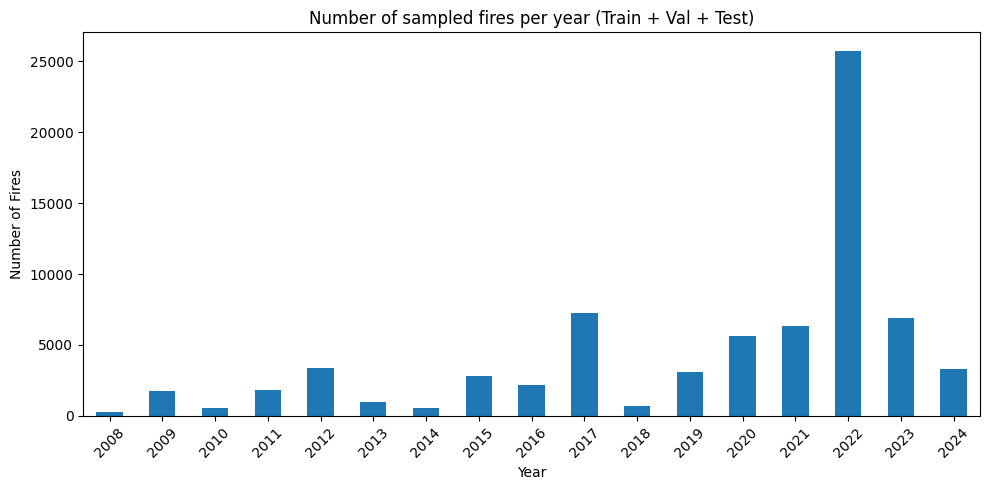

In [4]:
import matplotlib.pyplot as plt

# baseline_train, baseline_val, baseline_test already loaded earlier
all_baseline = pd.concat([baseline_train, baseline_val, baseline_test], ignore_index=True)

all_baseline["year"] = all_baseline["time"].dt.year
fires_per_year = all_baseline.groupby("year")["label"].sum().sort_index()

plt.figure(figsize=(10, 5))
fires_per_year.plot(kind="bar")
plt.title("Number of sampled fires per year (Train + Val + Test)")
plt.xlabel("Year")
plt.ylabel("Number of Fires")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

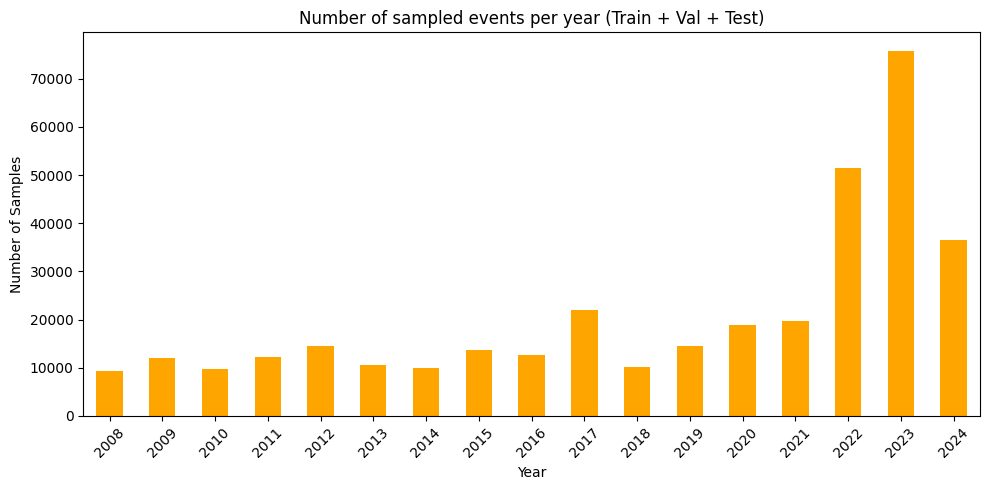

In [5]:
# number of SAMPLES per year (not just fires)
samples_per_year = all_baseline.groupby("year").size().sort_index()
plt.figure(figsize=(10, 5))
samples_per_year.plot(kind="bar", color="orange")
plt.title("Number of sampled events per year (Train + Val + Test)")
plt.xlabel("Year")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

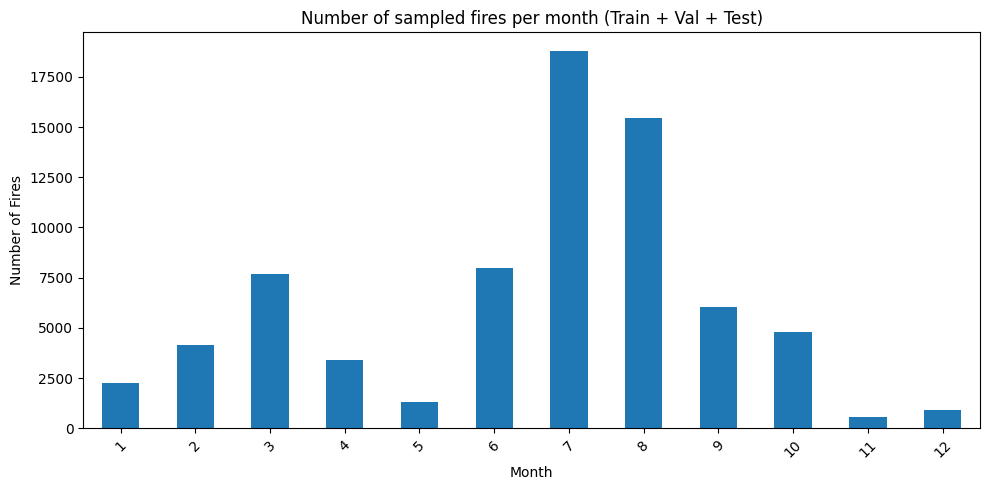

In [7]:
import matplotlib.pyplot as plt

# baseline_train, baseline_val, baseline_test already loaded earlier
all_baseline = pd.concat([baseline_train, baseline_val, baseline_test], ignore_index=True)

all_baseline["month"] = all_baseline["time"].dt.month
fires_per_month = all_baseline.groupby("month")["label"].sum().sort_index()

plt.figure(figsize=(10, 5))
fires_per_month.plot(kind="bar")
plt.title("Number of sampled fires per month (Train + Val + Test)")
plt.xlabel("Month")
plt.ylabel("Number of Fires")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

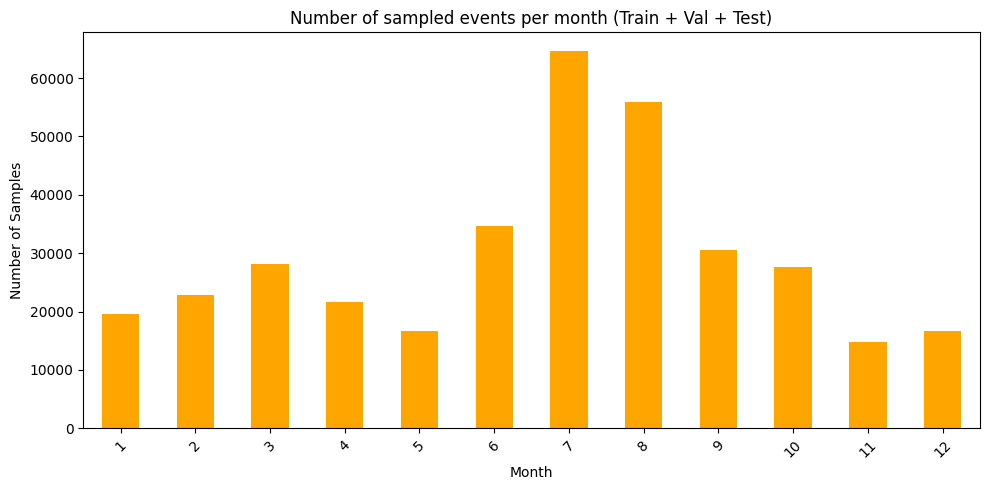

In [9]:
# number of SAMPLES per month (not just fires)
samples_per_year = all_baseline.groupby("month").size().sort_index()
plt.figure(figsize=(10, 5))
samples_per_year.plot(kind="bar", color="orange")
plt.title("Number of sampled events per month (Train + Val + Test)")
plt.xlabel("Month")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
# percentage of fire samples per split
def print_fire_percentage(df, split_name):
    total = len(df)
    fires = df["label"].sum()
    percentage = (fires / total) * 100 if total > 0 else 0
    print(f"{split_name}: {fires}/{total} fire samples ({percentage:.2f}%)")
print_fire_percentage(baseline_train, "Train")
print_fire_percentage(baseline_val, "Validation")
print_fire_percentage(baseline_test, "Test")

Train: 63149/241282 fire samples (26.17%)
Validation: 6899/75863 fire samples (9.09%)
Test: 3326/36579 fire samples (9.09%)
